# Lab 4: LQR Control of a Quadrotor

In this lab, we are going to use a hover state linearization of the quadrotor, like you wrote in the previous lab to allow the quadrotor to hover. First, we are going to import the various classes and functions we need.

This notebook is worth 65 points in total (Problem 1: 25 pts, Problem 2: 40 pts).

In [6]:
from quad_utils import plotting, CrazyflieBrushless as CF, animate_quad
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import solve_continuous_are
import scipy
from IPython.display import HTML, Image

## Problem 1 (25 Pts)

Now, in the cell below, you will fill out the function that will actually solve the LQR problem. That is, given the matrices $\mathbf{A}, \mathbf{B}, \mathbf{Q}, \mathbf{R}$, you should compute the $K$ that minimizes the LQR cost function. You are encouraged to use the function `scipy.linalg.solve_continuous_are` to solve the CARE. Also, we use the convention that the stabilizing control input is given by $\mathbf{u} = \mathbf{K}\mathbf{x}$ (as opposed to $\mathbf{u} = -\mathbf{K}\mathbf{x}$).

In [9]:
def lqr(A: np.ndarray, B: np.ndarray, Q: np.ndarray, R: np.ndarray) -> np.ndarray:
    # TODO: Solve the continuous-time algebraic Riccati equation and return the gain matrix K
    # (convention: u = K x)
    S = -1 * solve_continuous_are(A, B, Q, R)
    K = np.linalg.inv(R) @ B.T @ S
    return K

## Problem 2 (40 Pts)

Finally, you will use all the code you have written thus far to actually stabilize your Crazyflie. The following code implements a version of the Crazyflie class from our `quad_utils` library that uses the linearization and LQR functions you just wrote. This class is useful as it provides simulation and animation functionality to verify your controller is working. It also saves out $\mathbf{K}$ so it can be loaded onto the actual quadrotor for control. You will need to adjust the gains yourself, but we filled in a few for you to get started.

### LQR Simulation

The code for this problem is broken into two sections: designing the LQR controller and running the Crazyflie. 

The following cell uses the `lqr` function you just wrote in conjunction with our implementation of the linearization function from the previous lab (here as `self.hover_state_linearization()`) to create an instance of the `CrazyflieLQR` class. The details of this process are not important, but this class provides a lot of functionality for designing the LQR controller. It also saves the $\mathbf{K}$ matrix out as `quad_data/lqr_gains.npy`. Run this block to set your gains.

In [10]:
class CrazyflieLQR(CF):
    def __init__(self, Q: np.ndarray, R: np.ndarray, hover_pos: np.ndarray):
        super().__init__()
        self._hover_pos = hover_pos
        self._hover_state = np.concatenate([self._hover_pos, np.zeros(9)])
        A, B =  self.hover_state_linearization()
        self._K = lqr(A, B, Q, R)
        
        print('Using K matrix:')
        print()
        print(self._K)
        
        np.save('quad_data/lqr_gains', self._K)
        
    @property
    def K(self) -> np.ndarray:
        return self._K
    
    def controller(self, state: np.ndarray, t: float) -> np.ndarray:
        return self._K @ (state - self._hover_state) + np.array([self.mass * self.gravity, 0, 0, 0])

# The first argument is the Q matrix, the second is the R matrix. You can disregard the third argument.
quad = CrazyflieLQR(np.diag([1000, 1000, 2000, 0.001, 0.001, 1, 100, 100, 1, 0.005, 0.005, 1]), 2 * np.diag([1e5, 6e9, 6e9, 1e4]), np.zeros(3))


Using K matrix:

[[-1.22262318e-13  0.00000000e+00 -1.00000000e-01  0.00000000e+00
   3.14147141e-13  0.00000000e+00 -1.07642851e-13  0.00000000e+00
  -8.94706656e-02  0.00000000e+00 -7.11599942e-14  0.00000000e+00]
 [ 0.00000000e+00 -2.88675135e-04  0.00000000e+00 -9.93479866e-04
   0.00000000e+00 -1.43038388e-18  0.00000000e+00 -2.58577848e-04
   0.00000000e+00 -2.22583177e-04  0.00000000e+00 -2.05494018e-21]
 [ 2.88675135e-04  0.00000000e+00 -6.10814869e-15  0.00000000e+00
  -1.02491729e-03  0.00000000e+00  2.62134671e-04  0.00000000e+00
  -1.77857744e-15  0.00000000e+00 -2.33828259e-04  0.00000000e+00]
 [ 0.00000000e+00  5.86949571e-14  0.00000000e+00  8.48715775e-14
   0.00000000e+00 -7.07106781e-03  0.00000000e+00  3.92069119e-14
   0.00000000e+00 -5.66832492e-16  0.00000000e+00 -7.12509739e-03]]


This next cell simulates the quadrotor flying with a random initial condition for five seconds and plots some of the states. You should see the system stabilize for most choices of the random initial conditions, or your gains will almost certainly not work on the real Crazyflie. Feel free to change the plotted variables.

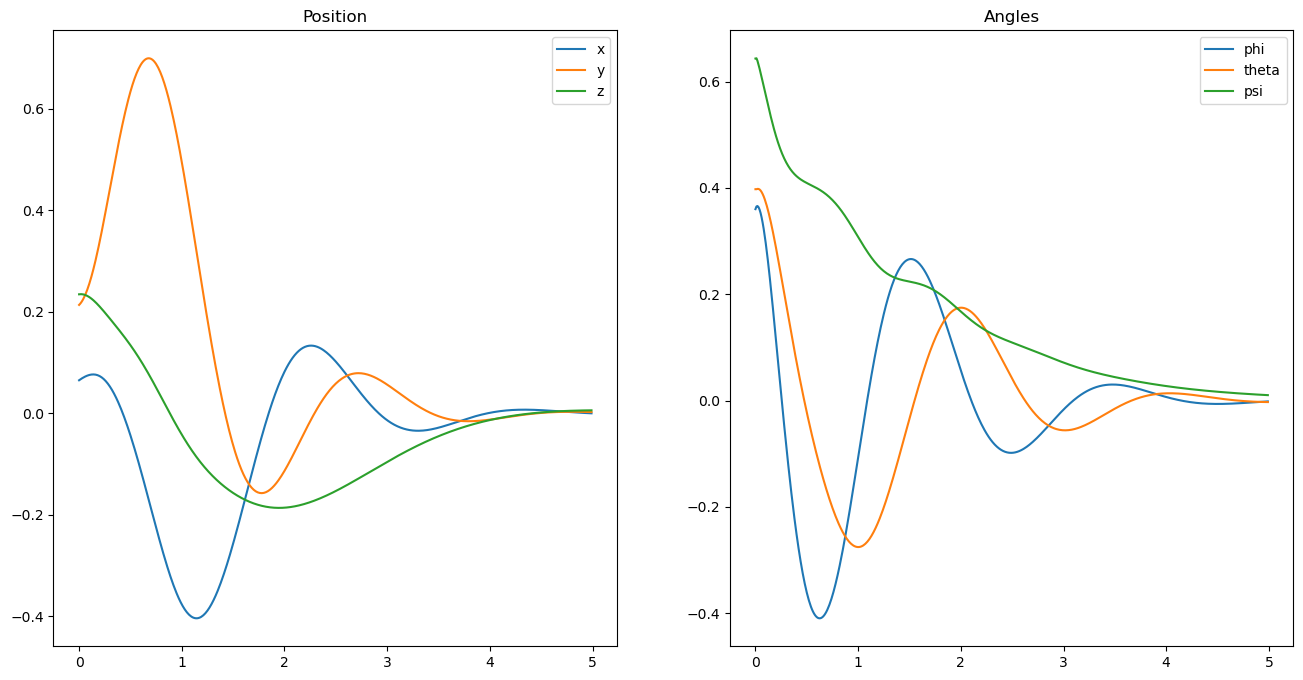

In [11]:
# Uncomment the following line if you want to use the same random initial condition.
# np.random.seed(0)

ic = np.random.rand(12) * 1.2
ic[0:3] = ic[0:3] / 5
ic[6:9] = ic[6:9] / 5

times, states, inputs = quad.simulate(ic, 5, 0.01, clip_input=False)

#%matplotlib notebook
plt.rcParams["figure.figsize"] = (16,8)
fig = plt.figure()

ax = fig.add_subplot(121, title='Position')
ax.plot(times, states[0, :], label='x')
ax.plot(times, states[1, :], label='y')
ax.plot(times, states[2, :], label='z')
ax.legend()

ax = fig.add_subplot(122, title='Angles')
ax.plot(times, states[3, :], label='phi')
ax.plot(times, states[4, :], label='theta')
ax.plot(times, states[5, :], label='psi')
ax.legend()

This cell optionally animates the simulation data computed and plotted in the previous cell.

In [12]:
animate_quad(0.1, states).save('./anim.gif', writer='pillow', fps=100)
Image(url='./anim.gif')

## Running the Quadrotor

### Setup

Now that you have a set of LQR gains you are happy with trying out, it's time to put them on the quadrotor. The quadrotor runs our modified version of the Crazyflie's firmware. Our modifications apply the LQR control law in real time --- i.e. much faster than we could do with Python over the radio.

**The TAs have already flashed this firmware onto all course drones, so you can skip this step.** You only need it if a TA asks you to re-flash your drone. In that case, first power the drone off. Then, hold the power switch down for about 3 seconds until the blue LED flashes, then release. After releasing, two blue LEDs should be flashing.  Then, open up your terminal and enter the following commands:

```
cd firmware-precompiled
python3 -m cfloader flash cf21bl.bin stm32-fw
```

(On Windows, use `python` instead of `python3`.)

(`cf21bl.bin` is for the Crazyflie 2.1 Brushless. If you have an older brushed Crazyflie 2.0/2.1, flash `cf2.bin` instead and use `Crazyflie` instead of `CrazyflieBrushless` in the import cell above.)

(**Note**: You should make sure that there are no other drones powered on in the vicinity of your drone. Otherwise the firmware update is likely to fail due to interference from other drones.)

Once this is completed, your Crazyflie should restart and play a jingle. If all the lights are on, not flashing, and no jingle plays, repeat the flashing process.

### Flying

To test out the quadrotor, simply run the cells below after placing it in the netted area. The drone will take off and land using the Crazyflie's own PID controller, but your LQR controller will stabilize the drone once it is hovering half a meter off the ground. **So the flight sequence you'll see is as follows: (1) drone's own PID controller (take-off), (2) your LQR controller, (3) drone's own PID controller (landing).**

The brushless Crazyflie will not spin its motors until it has been *armed*; the flight cell below does this for you (`cf.platform.send_arming_request(True)`) right after connecting. Keep fingers clear of the propellers from that point on. Arming requires a recent `cflib` (`pip install --upgrade cflib`).

If you see an error about something missing in the Log TOC (e.g. `stabilizer.controller not in param TOC`), this most likely means your computer lost connection with the drone midflight. (**Warning**: When you are testing your LQR controller, it can cause interference with other drones' LQR controllers. The LQR only runs for 5 seconds, so we recommend staggering the use of the following cell with other groups that are in same drone testing area to avoid interference issues.)

### Submission

You must submit the following to confirm that you got the drone to hover successfully:
- A video of your drone hovering
- The file `quad_data/quad_traj.npz`
- This notebook file

Please submit a zip file containing these to the **Lab 4** assignment on Gradescope.

You will be graded according to the data in `quad_data/quad_traj.npz`, which is plotted below. The tracking error is the largest error in x and in y over the full 5 seconds of LQR flight. The rubric is the following:
- If tracking error in x and y each below 75 cm: 10 points
- If tracking error in x and y each below 50 cm: 20 points
- If tracking error in x and y each below 25 cm: 30 points

When you are ready to test on the Crazyflie, set your gains in the next cell, then run the following cell.

In [ ]:
# We have two sets of gains for you to begin with for tuning. 
# Feel free to try both and choose one to be your starting point. 
# SET GAINS HERE

# Set 1
Q = np.diag([10, 10, 200, 0.1, 0.1, 10, 30, 30, 1, 10000, 10000, 0.1])
R = 2 * np.diag([1e5, 6e9, 6e9, 1e5])

# Set 2
# Q = np.diag([100, 100, 10000, 0.01, 0.01, 0.1, 5, 5, 500, 1000, 1000, 10])
# R = 2 * np.diag([4e6, 5e9, 7e9, 3e5])

quad = CrazyflieLQR(Q, R, np.zeros(3))

In [ ]:
group_number = 1  # TODO: set this to your drone's radio channel number

In [ ]:
import logging
import random
import time
import numpy as np

import cflib.crtp
from cflib.crazyflie import Crazyflie
from cflib.crazyflie.syncCrazyflie import SyncCrazyflie
from cflib.crazyflie.log import LogConfig
from cflib.crazyflie.syncLogger import SyncLogger

URI = f'radio://0/{group_number}/2M'

# Only output errors from the logging framework
logging.basicConfig(level=logging.ERROR)

log_keys = ['e_x',
            'e_y',
            'e_roll',
            'e_pitch',
            'u2_pwm',
            'u3_pwm',]

other_log_keys = []

if __name__ == '__main__':
    cflib.crtp.init_drivers(enable_debug_driver=False)

    with SyncCrazyflie(URI, cf=Crazyflie(rw_cache='./cache')) as scf:
        cf = scf.cf

        lg_stab = LogConfig(name='LQR', period_in_ms=10)
        lg_data = {}

        for key in log_keys:
            lg_stab.add_variable('ctrlLQR.' + key, 'float')
            lg_data[key] = []

        for key in other_log_keys:
            lg_stab.add_variable( key, 'float')
            lg_data[key.split('.')[1]] = []

        for i in range(4):
            for j in range(12):
                cf.param.set_value(f'ctrlLQR.k{i + 1}{j + 1}', '{:.10f}'.format(quad.K[i, j]))

        # Make the drone's hover feed-forward (m * g) use the same mass as our model.
        cf.param.set_value('ctrlLQR.mass', '{:.5f}'.format(quad.mass))

        print('Loaded LQR gain matrix.')
        print('Initializing as PID')
        cf.param.set_value('stabilizer.controller', '1')

        # The brushless Crazyflie requires arming before the motors will run.
        print('Arming')
        cf.platform.send_arming_request(True)
        time.sleep(1.0)

        cf.param.set_value('kalman.resetEstimation', '1')
        time.sleep(0.1)
        cf.param.set_value('kalman.resetEstimation', '0')
        time.sleep(2)

        print('Reset Kalman filter.')
        print('Taking off!')

        for y in range(10):
            # Position setpoints (not velocity-mode hover setpoints) so the PID holds x = y = 0 and the
            # LQR starts near its reference instead of wherever the drone drifted to.
            cf.commander.send_position_setpoint(0, 0, y / 25, 0)
            #cf.commander.send_stop_setpoint()
            time.sleep(0.1)

        for _ in range(50):
            cf.commander.send_position_setpoint(0, 0, 0.5, 0)
            #cf.commander.send_stop_setpoint()
            time.sleep(0.1)

        print('Switching to LQR!')
        cf.param.set_value('stabilizer.controller', '6')  # 6 = LQR in the MAE345 firmware

        with SyncLogger(scf, lg_stab) as logger:
            t_start = time.time()
            entry_count = 0

            for log_entry in logger:
                cf.commander.send_hover_setpoint(0, 0, 0, 0.5)
                for key, value in log_entry[1].items():
                    lg_data[key.split('.')[1]].append(value)

                entry_count += 1

                if time.time() - t_start > 5:
                    break

        print('Saving data...')
        for key in lg_data.keys():
            lg_data[key] = np.array(lg_data[key])

        np.savez('quad_data/quad_traj', **lg_data)

        print('Switching to PID!')
        cf.param.set_value('stabilizer.controller', '1')

        for _ in range(60):
            cf.commander.send_hover_setpoint(0, 0, 0, 0.5)
            time.sleep(0.1)

        for y in range(10):
            cf.commander.send_hover_setpoint(0, 0, 0, (10 - y) / 25)
            time.sleep(0.1)

        for i in range(10):
            cf.commander.send_stop_setpoint()
            time.sleep(0.1)

        cf.platform.send_arming_request(False)

print('Done!') 

Finally, this cell plots the result of your physical experiments, i.e. the data logged by the most recent run of the flight cell above in `quad_data/quad_traj.npz`. If you run it before flying the quadrotor, it will error since there is currently no flight data present. The output of the next cell _must_ be included in the notebook when you submit.

In [ ]:
import os

if os.path.isfile('quad_data/quad_traj.npz'):
    npzfile = np.load('quad_data/quad_traj.npz')
    t = np.arange(len(npzfile['e_x'])) * 0.01  # logged every 10 ms

    plt.rcParams["figure.figsize"] = (16,8)
    fig = plt.figure()

    ax = fig.add_subplot(311, title='Position')
    ax.plot(t, npzfile['e_x'], label='x')
    ax.plot(t, npzfile['e_y'], label='y')
    ax.legend()

    ax = fig.add_subplot(312, title='Angles')
    ax.plot(t, npzfile['e_roll'], label='phi')
    ax.plot(t, npzfile['e_pitch'], label='theta')
    ax.legend()

    ax = fig.add_subplot(313, title='Moments')
    ax.plot(t, npzfile['u2_pwm'] / (2 ** 15), label='M1')
    ax.plot(t, npzfile['u3_pwm'] / (2 ** 15), label='M2')
    ax.set_xlabel('Time since switching to LQR (s)')
    ax.legend()

    print('Max tracking error: x = {:.1f} cm, y = {:.1f} cm'.format(100 * np.abs(npzfile['e_x']).max(), 100 * np.abs(npzfile['e_y']).max()))
else:
    print('No flight data found.')